In [1]:
import numpy as np
np.set_printoptions(threshold = np.inf)
import re
import openpnm as op
import heapq as hq
import matplotlib.pyplot as plt
from collections import deque
from tqdm.auto import tqdm
import scipy.sparse as sprs
from scipy.sparse import csgraph
from scipy.sparse.csgraph import connected_components
from openpnm._skgraph.simulations import bond_percolation, site_percolation
import os
current_directory = os.getcwd()
print(current_directory)

/home/gladys/Documents/Jupyter_projects/NewOpenPNM/Report_2024_final


In [2]:
import warnings
from pathlib import Path

### Following the instructions from https://github.com/likeduck/SimulationExample-OpenPNM/blob/main/PNM%E5%89%8D%E5%A4%84%E7%90%86.py

In [3]:
ws=op.Workspace()
proj = ws.new_project()

In [4]:
path = './Sandstone_Berea/'
file_name = 'Berea'
project = op.io.network_from_statoil(path,file_name)
pn = project.network

In [5]:
pn['pore.diameter'] = pn['pore.radius']*2
pn['throat.diameter'] = pn['throat.radius']*2
pn['pore.left'] = pn['pore.inlets']
pn['pore.right'] = pn['pore.outlets']

In [6]:
del pn['pore.inlets']
del pn['pore.outlets']
del pn['pore.radius']
del pn['throat.radius']
del pn['pore.clay_volume']
del pn['throat.clay_volume']

# Defining the Conduit lengths 

In [7]:
# Form the 2D NumPy array with shape (Nt, 3)
pn['throat.conduit_lengths'] = np.vstack([
    pn['throat.conduit_lengths.pore1'],
    pn['throat.conduit_lengths.throat'],
    pn['throat.conduit_lengths.pore2']
]).T

# Cleaning Up the network topology

### This way is more effective than the presented in the V2 example

In [8]:
# Check PNM health & Trim
pn.add_model(propname='pore.cluster_number',
             model=op.models.network.cluster_number)
pn.add_model(propname='pore.cluster_size',
             model=op.models.network.cluster_size)
print(pn)
#print(pn['pore.cluster_number'])  
#print(pn['pore.cluster_size']) # it is from here that it comes the number 6004 
                               # you have to see the    
# Ps = pn['pore.cluster_size'] < 6004
# op.topotools.trim(network=pn, pores=Ps)


══════════════════════════════════════════════════════════════════════════════
net : <openpnm.network.Network at 0x7376c304ec60>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  throat.conns                                                12098 / 12098
  3  throat.shape_factor                                         12098 / 12098
  4  throat.total_length                                         12098 / 12098
  5  throat.length                                               12098 / 12098
  6  throat.conduit_lengths.throat                               12098 / 12098
  7  throat.volume                                               12098 / 12098
  8  throat.conduit_lengths.pore1                                12098 / 12098
  9  throat.conduit_lengths.pore2                                12098 / 12098
 

In [9]:
Ps = pn['pore.cluster_size']< 6004
op.topotools.trim(network=pn, pores=Ps)

In [10]:
geo = op.models.collections.geometry.spheres_and_cylinders
pn.add_model_collection(geo)
print(pn)


══════════════════════════════════════════════════════════════════════════════
net : <openpnm.network.Network at 0x7376c304ec60>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  throat.conns                                                12067 / 12067
  3  throat.shape_factor                                         12067 / 12067
  4  throat.total_length                                         12067 / 12067
  5  throat.length                                               12067 / 12067
  6  throat.conduit_lengths.throat                               12067 / 12067
  7  throat.volume                                               12067 / 12067
  8  throat.conduit_lengths.pore1                                12067 / 12067
  9  throat.conduit_lengths.pore2                                12067 / 12067
 

In [11]:
# This does not work due to the throats sizes vs pore sizes
# hsf_model = op.models.geometry.hydraulic_size_factors.spheres_and_cylinders
# pn.add_model(propname='throat.hydraulic_size_factors',
#              model= hsf_model)
# print(pn)

In [12]:
# net_health= op.utils.check_network_health(network=pn)
# print(net_health)
# net_health_merged = np.union1d(net_health['isolated_pores'],net_health['disconnected_pores'])
# op.topotools.trim(network= pn,pores=net_health_merged)

## Visualization of the diameter distribution after trimming

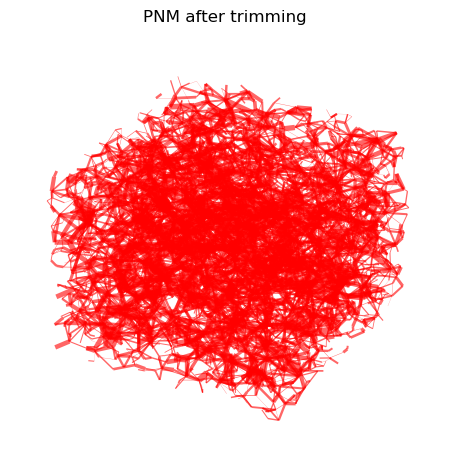

In [13]:
#ax = op.visualization.plot_coordinates(network=pn, c='g', markersize=pn['pore.diameter']*1e5, edgecolor='k', alpha=1)
ax = op.visualization.plot_connections(network=pn, c='r', linewidth=pn['throat.diameter']*1e5, alpha=0.6) #, ax=ax)
plt.title('PNM after trimming')
plt.axis('off')
plt.tight_layout()

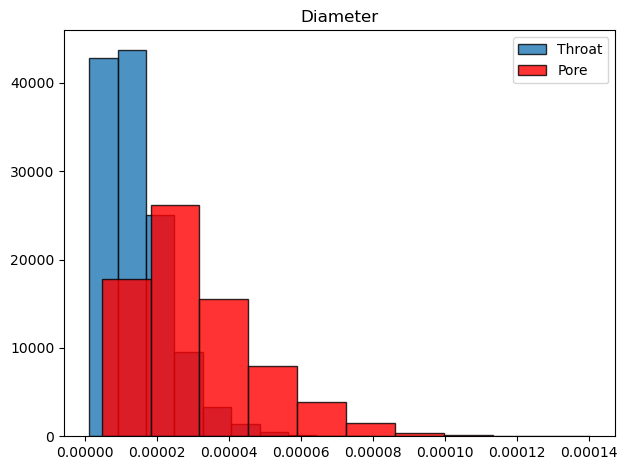

In [14]:
fig, ax = plt.subplots()
ax = plt.hist(pn['throat.diameter'], edgecolor='k', density=True, alpha=0.8, label='Throat')
ax = plt.hist(pn['pore.diameter'], color='r', edgecolor='k', density=True, alpha=0.8, label='Pore')
plt.title('Diameter')
plt.tight_layout()
plt.legend()

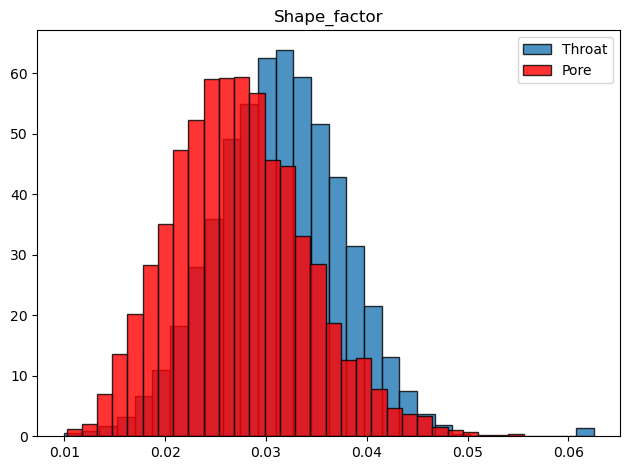

In [15]:
fig, ax = plt.subplots()
ax = plt.hist(pn['throat.shape_factor'], edgecolor='k', bins=30, density=True, alpha=0.8, label='Throat')
ax = plt.hist(pn['pore.shape_factor'], color='r', edgecolor='k', bins=30, density=True, alpha=0.8, label='Pore')
plt.title('Shape_factor')
plt.tight_layout()
plt.legend()

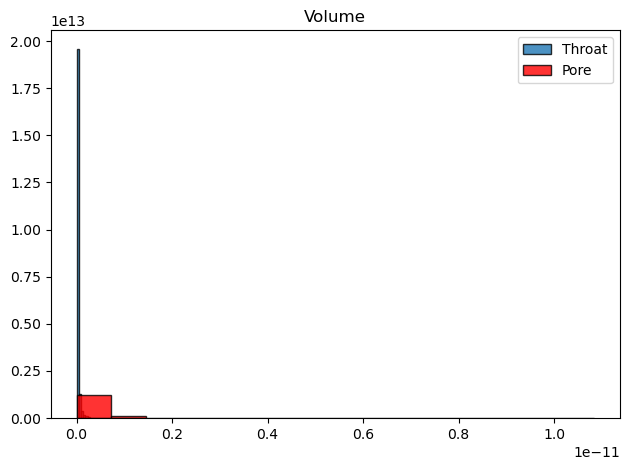

In [16]:
fig, ax = plt.subplots()
ax = plt.hist(pn['throat.volume'], edgecolor='k', bins=15, density=True, alpha=0.8, label='Throat')
ax = plt.hist(pn['pore.volume'], color='r', edgecolor='k', bins=15, density=True, alpha=0.8, label='Pore')
plt.title('Volume')
plt.tight_layout()
plt.legend()
plt.show()

In [17]:
## Redefining the right and left boundaries 

In [18]:
bound_frac = 0.05
Lx = max(pn['pore.coords'][:,0])-min(pn['pore.coords'][:,0])
pn['pore.inlets'] = pn['pore.coords'][:,0]<=bound_frac*Lx
pn['pore.outlets'] = pn['pore.coords'][:,0]>=(1-bound_frac)*Lx
Inlets = np.where(pn['pore.inlets'])
Outlets = np.where(pn['pore.outlets'])
print(np.size(Inlets))
print(np.size(Outlets))

313
421


In [19]:
## Getting the matrix that relates pores and throats

In [20]:
incidence_m = pn.network.create_incidence_matrix(fmt='csr')

In [21]:
P_inside = np.setdiff1d(pn.pores(),Outlets)

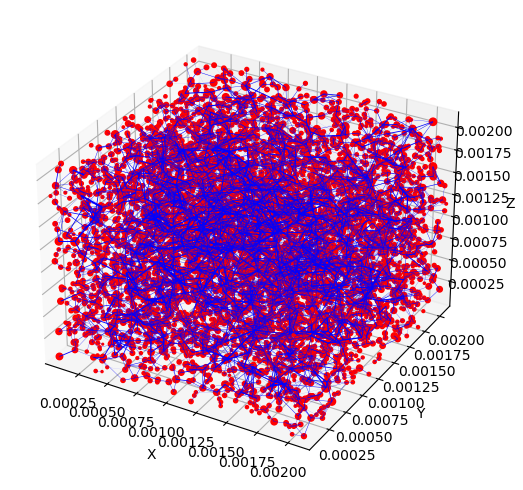

In [22]:
fig, ax = plt.subplots(figsize=[5, 5])
op.visualization.plot_coordinates(ax=fig,
                                  network=pn,
                                  size_by=pn["pore.diameter"],
#                                  color_by=Diff["pore.concentration"], 
                                  markersize=50)
op.visualization.plot_connections(ax=fig,
                                  network=pn,
                                  size_by=pn["throat.diameter"],
#                                  color_by=Diff["pore.concentration"], 
                                  linewidth=1.5)
plt.savefig(f"3D_Berea_Hys/PN_Berea.png")

# Set Phases Oil-Water

In [23]:
oil = op.phase.Phase(network=pn,name='oil')
oil['pore.surface_tension'] = 0.030
oil['pore.contact_angle'] = 100
oil['pore.viscosity'] = 1.39e-3
oil['throat.viscosity'] = 1.39e-3
oil['pore.density'] = 900
oil['throat.density'] = 900
oil['pore.occupancy'] = np.zeros(pn.Np, dtype=bool)
oil['throat.occupancy'] = np.zeros(pn.Nt, dtype=bool)
model = op.models.physics.capillary_pressure.washburn
oil.add_model(propname='throat.entry_pressure',
               model = model)
model1 = op.models.physics.hydraulic_conductance.valvatne_blunt
oil.add_model(propname='throat.hydraulic_conductance',
               model=model1) 
#oil.add_model_collection(op.models.collections.physics.basic)
oil.regenerate_models()
#print('Esta throat conduit hydraulic conductance?',oil['throat.hydraulic_conductance'])

In [24]:
water = op.phase.Phase(network=pn,name='water')
water['pore.surface_tension'] = 0.030
water['pore.contact_angle'] = 80
water['pore.viscosity'] = 1.05e-3
water['throat.viscosity'] = 1.05e-3
water['pore.density'] = 996.95
water['throat.density'] = 996.95
water['pore.occupancy'] = np.zeros(pn.Np, dtype=bool)
water['throat.occupancy'] = np.zeros(pn.Nt, dtype=bool)
water.add_model(propname='throat.entry_pressure',
                model = model)
water.add_model(propname='throat.hydraulic_conductance',
                model=model1) 
#water.add_model_collection(op.models.collections.physics.basic)
water.regenerate_models()

In [25]:
def bfs_from_initial_pore(initial_pore, throats, conns, incidence_matrix, outlet_pores, throat_mask, pore_mask):
    """
    Performs BFS to find possible paths from the initial_pore to any outlet pore,
    starting from specified throats.

    Parameters:
    - initial_pore (int): The index of the initial pore.
    - throats (list): List of throat indices to start the BFS from.
    - conns (np.ndarray): Array of connected pores for each throat (shape: [n_throats, 2]).
    - incidence_matrix (csr_matrix): Incidence matrix between pores and throats.
    - outlet_pores (list or np.ndarray): Indices of outlet pores.
    - throat_mask (np.ndarray): Boolean array indicating active throats (True if active).
    - pore_mask (np.ndarray): Boolean array indicating active pores (True if active).

    Returns:
    - list: The shortest valid path as a list of throat indices, or an empty list if no path is found.
    """

    # Filter the provided throats based on the throat_mask
    throats_to_explore = [throat for throat in throats if throat_mask[throat]]
    # print('Throats to start BFS from:', throats_to_explore)

    # Initialize the BFS queue with specified throats
    queue = deque()
    for throat in throats_to_explore:
        # Start paths from the initial_pore via each specified throat
        queue.append((throat, [throat], set([initial_pore])))

    visited_throats = set()
    valid_paths = []

    while queue:
        current_throat, path, visited_pores_in_path = queue.popleft()

        if current_throat in visited_throats:
            continue  # Skip if already visited
        visited_throats.add(current_throat)

        # Get the pores connected by the current throat
        connected_pores = conns[current_throat]

        # Exclude already visited pores
        next_pores = [pore for pore in connected_pores if pore not in visited_pores_in_path and pore_mask[pore]]

        for pore in next_pores:
            new_visited_pores = visited_pores_in_path.union([pore])

            # Check if the pore is an outlet pore
            if np.isin(pore,outlet_pores):
                valid_paths.append(path)
                continue  # Found a path to an outlet pore

            # Get neighboring throats from the current pore
            neighbor_throats = incidence_matrix[pore, :].nonzero()[1]
            neighbor_throats = [t for t in neighbor_throats if throat_mask[t] and t not in visited_throats]

            for next_throat in neighbor_throats:
                # Avoid cycles by not revisiting throats
                queue.append((next_throat, path + [next_throat], new_visited_pores))

    # Return the shortest valid path if any are found
    if valid_paths:
        #shortest_path = min(valid_paths, key=len)
        #print('Shortest valid path found:', shortest_path)
        return valid_paths
    else:
        #print('No valid path found from pore', initial_pore, 'to outlet pores.')
        return []  # No valid path found

# Absolute Permeability with oil before Drainage

In [26]:
BD_flow_oil = op.algorithms.StokesFlow(network=pn, phase=oil)
BD_flow_oil.set_value_BC(pores=[Inlets], values=1)
BD_flow_oil.set_value_BC(pores=[Outlets], values=0)
BD_flow_oil.run()
Inlet_flow_BD_oil = np.absolute(BD_flow_oil.rate(pores=[Inlets]))
print(Inlet_flow_BD_oil)
# print(BD_flow_oil['pore.pressure'][Inlets])
# print(BD_flow_oil.rate(pores=Inlets, mode='single'))

[1.92597094e-12]


In [27]:
BD_flow_water = op.algorithms.StokesFlow(network=pn, phase=water)
BD_flow_water.set_value_BC(pores=[Inlets], values=1)
BD_flow_water.set_value_BC(pores=[Outlets], values=0)
BD_flow_water.run()
Inlet_flow_BD_water = np.absolute(BD_flow_water.rate(pores=[Inlets]))
print(Inlet_flow_BD_water)
# print(BD_flow_water['pore.pressure'][Inlets])
# print(BD_flow_water.rate(pores=Inlets, mode='single'))

[2.54961868e-12]


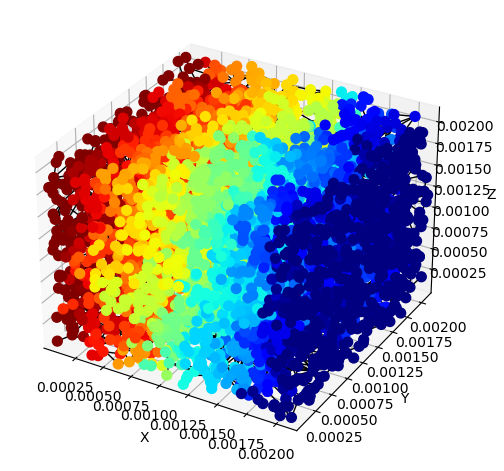

In [28]:
ax = op.visualization.plot_connections(network=pn, color_by=BD_flow_oil.rate(throats=pn.Ts, mode='single'))
op.visualization.plot_coordinates(network=pn, color_by=BD_flow_oil['pore.pressure'], ax=ax, markersize=50)
plt.savefig(f"3D_Berea_Hys/Oil_Stokes_BD_Berea.png")


# Drainage - Oil Invasion

In [29]:
Max_seq =1e8
ip = {}
ip['throat.invasion_pressure'] = np.zeros(pn.Nt, dtype=float)
ip['pore.invasion_pressure'] = np.zeros(pn.Np, dtype=float)
ip['throat.invasion_sequence'] = np.full(pn.Nt,Max_seq,dtype=int)
ip['pore.invasion_sequence'] = np.full(pn.Np,Max_seq,dtype=int)

In [30]:
Pinv = np.zeros(pn.Np, dtype=bool)  # Pre-allocate array for storing pore invasion state
Tinv = np.zeros(pn.Nt, dtype=bool)  # Pre-allocate array for storing throat invasion state

In [31]:
Pinv[Inlets] = True

In [32]:
Ts1 = pn.find_neighbor_throats(pores=Inlets, mode='xor', asmask=False)
# print(Ts1)
Ts2 = pn.find_neighbor_throats(pores=Outlets, mode='xor', asmask=False)
# print(Ts2)

In [33]:
# list of the throats linked to the Inlet pores that are candidates to be invided
q = [(oil['throat.entry_pressure'][i], i ) for i in Ts1]
#Sort for the minimum  Capillary pressure of the throats that candidates to be invaded
hq.heapify(q)
#print(q)

In [34]:
hi = 4 * oil['throat.entry_pressure'].max()
low = 0.9 * oil['throat.entry_pressure'].min()

Global_T_entry_p = np.logspace(np.log10(low),np.log10(hi), 30)
#
#Global_T_entry_p = np.unique([item[0] for item in q])
print(Global_T_entry_p)

[  234.04717069   285.91877561   349.2866246    426.69861698
   521.26734009   636.7952204    777.92741178   950.33856822
  1160.96101071  1418.26346259  1732.59156058  2116.58383295
  2585.67987046  3158.74112256  3858.80928005  4714.0327371
  5758.7983841   7035.11423832  8594.29850555 10499.04298641
 12825.93379313 15668.53072977 19141.12915203 23383.35556369
 28565.78172974 34896.78303907 42630.916878   52079.15789327
 63621.40168447 77721.73967543]


In [35]:

#print(Global_T_entry_p)
counter = 0
counter_press = 0
ip['pore.invasion_sequence'][Pinv] = counter
ip['throat.invasion_sequence'][Tinv] = counter 

In [36]:
#Loop over pressures
for pressure in Global_T_entry_p:
    try:
        # print("Pressure",pressure)
        counter_press += 1
        int_pore_queue = list(P_inside)
        
        pressure_check = np.any(oil['throat.entry_pressure'][i] <= pressure for i in Ts1)
        
        if not pressure_check:
            # print('Not throat to be invaded at pressure',pressure)
            continue
    
        while len(int_pore_queue) > 0 :
            try:
                pore_index = hq.heappop(int_pore_queue)
                # Find neighboring throats of the current pore
                neighbor_throats = incidence_m[pore_index].nonzero()[1]
                # print('Neigh_throats',neighbor_throats)               
                can_invade = [(oil['throat.entry_pressure'][i],i) 
                              for i in neighbor_throats 
                              if oil['throat.entry_pressure'][i]<=pressure and Pinv[pore_index]]
                              
                if not can_invade:
                    # print('O poro', pore_index,'nao tem nenhuma garganta para invadir',can_invade)
                    continue
                
                throat_indices = [thr_indx for pres, thr_indx in can_invade]
                #throat_indices = np.array([thr_indx for pres, thr_indx in can_invade], dtype=int)
                                
                valid_paths = bfs_from_initial_pore(initial_pore=pore_index,
                                                    throats = throat_indices,
                                                    conns = pn.conns,
                                                    incidence_matrix=incidence_m,
                                                    outlet_pores=Outlets,
                                                    throat_mask=~Tinv,
                                                    pore_mask=~Pinv)
                
                if not valid_paths:
                    # print('O poro', pore_index,'nao tem valid path from BFS',can_invade)
                    continue
                      
                for i, path in enumerate(valid_paths, start=1):
                    # If path is empty
                    if not path:
                        # print(f'Path {i} is empty.')
                        continue
                        
                    filtered_elements = []
                    previous_passed = True
                            
                    for element in path:
                    
                        if previous_passed and oil['throat.entry_pressure'][element] <= pressure:
                            # Append only if it is the first element or if its the next to
                            # the last appended element
                            filtered_elements.append(element)
                            previous_pased = True
                        else:
                            previous_passed = False   #Break if continuity is lost 
                            break
                        
                    #Only update Invasion status if filtered elements contains contiguous elements started from throat_indices   
                    if not filtered_elements:
                        print('Nao tem elements in path', path,'elementos',filtered_elements)
                        continue
                    # Update invasion status
                    Tinv[filtered_elements] = True
                    ip['throat.invasion_pressure'][filtered_elements] = pressure
                    pores = pn.conns[filtered_elements]
                    Pinv[pores] = True
                    ip['pore.invasion_pressure'][pores] = pressure                           
                    
                    counter += 1
                    ip['throat.invasion_sequence'][filtered_elements] = counter
                    ip['pore.invasion_sequence'][pores] = counter 

            except Exception as e:
                print(f"Error in invading neighboring throats for pore {pore_index} at pressure {pressure}: {e}")
                raise  
                
        ax = op.visualization.plot_coordinates(network=pn, pores=Inlets, c='r', s=40)
        ax = op.visualization.plot_coordinates(network=pn, pores=Outlets, c='yellow', s=40, ax=ax)
        #ax = op.visualization.plot_coordinates(network=pn, pores=pn.pores('left', mode='not'), c='blue', s=20, ax=ax)
        ax = op.visualization.plot_connections(network=pn, throats=pn.throats(), c='blue', linewidth=0.5, ax=ax)
        op.visualization.plot_coordinates(network=pn, pores=Pinv, s=40, c='red', ax=ax)
        op.visualization.plot_connections(network=pn, throats=Tinv, c='red', linewidth=2, ax=ax)       
        plt.savefig(f"3D_Berea_Hys/Drain_Berea_{str(counter_press).zfill(3)}.png")
        plt.close()  
        
    except Exception as e:
         print(f"An error occurred at pressure {pressure}: {e}")
         raise  # Reraise the error for debugging purposes if needed

KeyboardInterrupt: 

In [ ]:
fig, ax = plt.subplots(figsize=[5, 5])
op.visualization.plot_coordinates(ax=fig,
                                  network=pn,
                                  size_by=ip["pore.invasion_pressure"]>0,
                                  color='red', 
                                  markersize=10)
op.visualization.plot_connections(ax=fig,
                                  network=pn,
                                  size_by=ip["throat.invasion_pressure"]>0,
                                  color='red', 
                                  linewidth=1)
op.visualization.plot_coordinates(ax=fig,
                                  network=pn,
                                  size_by=ip["pore.invasion_pressure"]==0,
                                  color='blue', 
                                  markersize=10)
op.visualization.plot_connections(ax=fig,
                                  network=pn,
                                  size_by=ip["throat.invasion_pressure"]==0,
                                  color='blue', 
                                  linewidth=1.5)
plt.savefig(f"3D_Berea_Hys/PressureDrain_Berea.png")

# Relative Permeability for Drainage

In [ ]:
def sat_occ_update(network, nwp, wp, ip, i):
    r"""
        Calculates the saturation of each phase using the invasion
        sequence from either invasion percolation.
        Parameters
        ----------
        network: network
        nwp : phase
            non-wetting phase
        wp : phase
            wetting phase
        ip : IP
            invasion percolation (ran before calling this function)
        i: int
            The invasion_sequence limit for masking pores/throats that
            have already been invaded within this limit range. The
            saturation is found by adding the volume of pores and thorats
            that meet this sequence limit divided by the bulk volume.
    """
    # Create masks for invaded pore/throats
    pore_mask = (ip['pore.invasion_sequence'] < i)
    throat_mask = (ip['throat.invasion_sequence'] < i )

    # Calculates volumes for wetting phase (non-invaded volumes)
    wp_sat_p = np.sum(network['pore.volume'][~pore_mask])
    wp_sat_t = np.sum(network['throat.volume'][~throat_mask])
    wp_sat = wp_sat_p + wp_sat_t
    bulk = network['pore.volume'].sum() + network['throat.volume'].sum()

    # Calculateas the Saturation of the weatting phase
    sat = wp_sat/bulk

    # Update the phase occupancy
    nwp['pore.occupancy'] = pore_mask
    nwp['throat.occupancy'] = throat_mask
    wp['throat.occupancy'] = ~throat_mask
    wp['pore.occupancy'] = ~pore_mask
    # print('oil occupancy \n',nwp['pore.occupancy'])
    # print('water occupancy \n',wp['pore.occupancy'])
    return sat

In [ ]:
def Rate_calc(network, phase, inlet, outlet, conductance):
    """
    Simulates stokes flow given the hydraulic conductance keyword 
    and returns the rate of inlet fluid flow.
    
    Parameters
    ----------
    network : network
    phase : phase
    inlet : array
        inlet pores
    outlet : array
        outlet pores
    conductance : str
        name of conductance model to use
    """
    phase.regenerate_models()
    St_p = op.algorithms.StokesFlow(network=network, phase=phase)
    St_p.settings._update({'conductance' : conductance})
    St_p.set_value_BC(pores=inlet, values=1)
    St_p.set_value_BC(pores=outlet, values=0)
    St_p.run()
    val = np.abs(St_p.rate(pores=inlet, mode='group'))
    
    return val

In [ ]:
model_mp_cond = op.models.physics.multiphase.conduit_conductance
oil.add_model(model=model_mp_cond, propname='throat.conduit_hydraulic_conductance',
              throat_conductance='throat.hydraulic_conductance', mode='medium', regen_mode='deferred')
water.add_model(model=model_mp_cond, propname='throat.conduit_hydraulic_conductance',
              throat_conductance='throat.hydraulic_conductance', mode='medium', regen_mode='deferred')

In [ ]:
start = 0
stop = 1000000
step = 1000
Swp = []
relperm_nwp = []
relperm_wp = []

In [ ]:
fig, ax = plt.subplots(figsize=[5, 5])
# op.visualization.plot_coordinates(network=pn, pores=~Pinv, s=20, c='red', ax=fig)
# op.visualization.plot_connections(network=pn, throats=~Tinv, c='blue', linewidth=1, ax=fig)
op.visualization.plot_coordinates(ax=fig,
                                  network=pn,
                                  #size_by=Pinv_ad.astype(int),
                                  size_by=(ip["pore.invasion_sequence"]<200000),
                                  color='red', 
                                  markersize=15)
op.visualization.plot_connections(ax=fig,
                                  network=pn,
                                  #size_by=Tinv_ad.astype(int),
                                  size_by=(ip["throat.invasion_sequence"]<200000),
                                  color='red', 
                                  linewidth=2)
# op.visualization.plot_coordinates(ax=fig,
#                                   network=pn,
#                                   #size_by=Pinv_ad.astype(int),
#                                   size_by=(ip["pore.invasion_sequence"]==1e6),
#                                   color='blue', 
#                                   markersize=20)
# op.visualization.plot_connections(ax=fig,
#                                   network=pn,
#                                   #size_by=Tinv_ad.astype(int),
#                                   size_by=(ip["throat.invasion_sequence"]==1e6),
#                                   color='blue', 
#                                   linewidth=2)
plt.savefig(f"3D_Berea_Hys/Drain_Berea.png")

In [ ]:
# Calculates volumes for wetting phase (non-invaded volumes)
p_mask_oil = (ip["pore.invasion_sequence"]<500000)
t_mask_oil = (ip["throat.invasion_sequence"]<500000)
p_mask_water = (ip["pore.invasion_sequence"]==1e8)
t_mask_water = (ip["throat.invasion_sequence"]==1e8)
oil_sat_p = np.sum(pn['pore.volume'][p_mask_oil])
oil_sat_t = np.sum(pn['throat.volume'][t_mask_oil])
water_sat_p = np.sum(pn['pore.volume'][p_mask_water])
water_sat_t = np.sum(pn['throat.volume'][t_mask_water])
oil_sat = oil_sat_p + oil_sat_t
water_sat = water_sat_p + water_sat_t
bulk = pn['pore.volume'].sum() + pn['throat.volume'].sum()

# Calculateas the Saturation of the weatting phase
sat_oil = oil_sat/bulk
sat_water = water_sat/bulk
print('sat_oil :', sat_oil)
print('sat_water :', sat_water)

In [ ]:
for i in range(start, stop, step):
    oil.regenerate_models()
    water.regenerate_models()
    sat = sat_occ_update(network=pn, nwp=oil, wp=water, ip=ip, i=i) 
    Swp.append(sat)
    Rate_abs_nwp = Rate_calc(pn, oil, Inlets, Outlets, 
                            conductance='throat.hydraulic_conductance')
    Rate_abs_wp = Rate_calc(pn, water, Inlets, Outlets, 
                           conductance='throat.hydraulic_conductance')
    Rate_enwp = Rate_calc(pn, oil, Inlets, Outlets, 
                          conductance = 'throat.conduit_hydraulic_conductance')
    Rate_ewp = Rate_calc(pn, water, Inlets, Outlets, 
                         conductance = 'throat.conduit_hydraulic_conductance')
    relperm_nwp.append(Rate_enwp/Rate_abs_nwp)
    relperm_wp.append(Rate_ewp/Rate_abs_wp)

In [ ]:
plt.figure(figsize=[6,5])
plt.plot(Swp, relperm_nwp, '*-', label='Kr_nwp')
plt.plot(Swp, relperm_wp, 'o-', label='Kr_wp')
plt.xlabel('Swp')
plt.ylabel('Kr')
plt.xlim(-0.05,1.05)
plt.ylim(-0.05,1.05)
plt.title('Relative Permeability in x direction')
plt.legend()
plt.savefig(f"3D_Berea_Hys/Krel_Drain_Berea.png")
plt.close()

In [ ]:
fig, ax = plt.subplots(figsize=[5, 5])
# op.visualization.plot_coordinates(network=pn, pores=~Pinv, s=20, c='red', ax=fig)
# op.visualization.plot_connections(network=pn, throats=~Tinv, c='blue', linewidth=1, ax=fig)
op.visualization.plot_coordinates(ax=fig,
                                  network=pn,
                                  #size_by=Pinv_ad.astype(int),
                                  # Remember the pressure is negative in Imbibition
                                  size_by=ip["pore.invasion_sequence"],
                                  color='blue', 
                                  markersize=30)
op.visualization.plot_connections(ax=fig,
                                  network=pn,
                                  #size_by=Tinv_ad.astype(int),
                                  # Remember the pressure is negative in Imbibition
                                  size_by=ip["throat.invasion_sequence"],
                                  color='blue', 
                                  linewidth=2)
# op.visualization.plot_coordinates(ax=fig,
#                                   network=pn,
#                                   size_by=Pinv_0,
#                                   color='red', 
#                                   markersize=20)
# op.visualization.plot_connections(ax=fig,
#                                   network=pn,
#                                   #size_by=Tinv_ad.astype(int),
#                                   size_by=Tinv_0,
#                                   color='red', 
#                                   linewidth=2.2)

plt.savefig(f"3D_Berea_Hys/PressureDrain_Berea.png")

# Oil Permeability after Drainage

As relative permeability is the ratio of effective over absolute permeability, given the same boundary condition and viscosity, the geometrical parameters in

will cancel out. The remaining fraction includes flow rates as follows:

Where is the inlet flow rate of the phase (water/air) for a Stokes flow algorithm with multiphase conduit_conductance assigned as conduit hydraulic conductance model to account for the existence of the other phase. Whereas

is the inlet flow rate of the phase (water/air) for a Stokes flow algorithm with generic_hydraulic_conductance assigned as hydraulic conductance model for a single phase flow.

Note that
is a property of the porous material, not the fluid. However, here to cancel out viscosity in the fraction, the same phase must be used to calculate . Therefore, naming abs-phase was used here to indicate the flow rate from a single phase flow algorithm for the same phase that relative permeability is being calculated. Therefore, we only need to find the rate values for calculating the relative permeability. 

In [ ]:
pore_mask_oil = (ip['pore.invasion_sequence'] < 15000)
throat_mask_oil = (ip['throat.invasion_sequence'] < 15000)
oil['pore.occupancy'] = pore_mask_oil
oil['throat.occupancy'] = throat_mask_oil

# Calculates volumes for wetting phase (non-invaded volumes)
oil_sat_p = np.sum(pn['pore.volume'][pore_mask_oil])
oil_sat_t = np.sum(pn['throat.volume'][throat_mask_oil])
oil_sat = oil_sat_p + oil_sat_t
bulk = pn['pore.volume'].sum() + pn['throat.volume'].sum()

# Calculateas the Saturation of the weatting phase
sat = oil_sat/bulk

print('volume of water',oil_sat,'total volume PN', bulk,'oil saturation', sat)

In [ ]:
oil.regenerate_models()
oil_flow = op.algorithms.StokesFlow(network=pn, phase=oil)
oil_flow.settings._update({'conductance' : 'throat.conduit_hydraulic_conductance'})
oil_flow.set_value_BC(pores=Inlets, values=1)
oil_flow.set_value_BC(pores=Outlets, values=0)
oil_flow.run()
oil_rate_after_dr = np.abs(oil_flow.rate(pores=Inlets, mode='group'))
print(oil_rate_after_dr)

In [ ]:
num = oil_rate_after_dr/Inlet_flow_BD_oil
print(num)

In [ ]:
ax = op.visualization.plot_connections(network=pn, color_by=oil_flow.rate(throats=pn.Ts, mode='single'))
ax= op.visualization.plot_coordinates(network=pn, color_by=oil_flow['pore.pressure'],markersize=50,ax=ax) 
plt.savefig(f"3D_Berea_Hys/Oil_Stokes_BP_Berea.png")

In [ ]:
print(np.min(oil['pore.pressure']))
print(np.max(oil['pore.pressure']))

# Imbibition

In [ ]:
Pinv_0 = Pinv
Tinv_0 = Tinv
P_trap = np.where(~Pinv)
T_trap = np.where(~Tinv)
New_P_inside = np.setdiff1d(P_inside,P_trap)
#print(New_P_inside)

In [ ]:
nTinv = np.size(T_trap)
nPinv = np.size(P_trap)
print(nTinv,nPinv)

In [ ]:
Max_seq1 = 1e6
ip_ad = {}
ip_ad['throat.invasion_pressure'] = np.zeros(pn.Nt, dtype=float)
ip_ad['pore.invasion_pressure'] = np.zeros(pn.Np, dtype=float)
ip_ad['throat.invasion_sequence'] = np.full(pn.Nt,Max_seq1,dtype=int)
ip_ad['pore.invasion_sequence'] = np.full(pn.Np,Max_seq1,dtype=int)
ip_ad['throat.invasion_sequence'][T_trap] = np.zeros(nTinv,dtype=int)
ip_ad['pore.invasion_sequence'][P_trap] = np.zeros(nPinv,dtype=int)

In [ ]:
Pinv_ad = np.zeros(pn.Np, dtype=bool)  # Pre-allocate array for storing pore invasion state
Tinv_ad= np.zeros(pn.Nt, dtype=bool)  # Pre-allocate array for storing throat invasion state

In [ ]:
Pinv_ad[Inlets] = True
# list of the throats linked to the Inlet pores that are candidates to be invided
q_ad = [(water['throat.entry_pressure'][i], i ) for i in Ts1]
#Sort for the minimum  Capillary pressure of the throats that candidates to be invaded
hq.heapify(q_ad)
#print(q_ad) 

In [ ]:
print(water['throat.entry_pressure'].max())
print(water['throat.entry_pressure'].min())

In [ ]:
# Here we set the entry pressure curve
max = 0.8 * water['throat.entry_pressure'].max()
min = 0.1 * water['throat.entry_pressure'].min()
steps = 20
x = np.linspace(0,1,steps)
print(max, min)
Global_T_entry_p_ad = min * (max/min) ** x  
#logspace(np.log10(low),np.log10(hi), Global_T_entry_p)
print(Global_T_entry_p_ad)

In [ ]:
counter1 = 0
counter_press_ad = 0
ip_ad['pore.invasion_sequence'][Pinv_ad] = counter1

In [ ]:
# Loop over pressures
for pressure1 in Global_T_entry_p_ad:
    try: 
        counter_press_ad += 1
        int_pore_queue = list(New_P_inside)

        pressure_check1 = np.any(water['throat.entry_pressure'][i] <= pressure1 for i in Ts1)
        #print('At pressure',pressure,'which inlet throats',pressure_check1)
      
        if not pressure_check1:
             #print('Not throat to be invaded at pressure',pressure1)
             continue

        while len(int_pore_queue) > 0 :
            try:
                pore_index = hq.heappop(int_pore_queue)
                #print('Pore', pore_index)
                # Find neighboring throats of the current pore
                neighbor_throats = incidence_m[pore_index].nonzero()[1]
                #print('Neigh_throats',neighbor_throats)
             
                can_invade1 = [(water['throat.entry_pressure'][i],i) 
                              for i in neighbor_throats 
                              if water['throat.entry_pressure'][i]<=pressure1 and Pinv_ad[pore_index]]
                #print(can_invade1)
                if not can_invade1:
                    #print('O poro', pore_index,'nao tem nenhuma garganta para invadir',can_invade1)
                    continue

                # print('throats can be invaded',can_invade1)
                
                throat_indices = [thr_indx for pres, thr_indx in can_invade1]
                                
                valid_paths = bfs_from_initial_pore(initial_pore = pore_index,
                                                    throats = throat_indices,
                                                    conns = pn.conns,
                                                    incidence_matrix = incidence_m,
                                                    outlet_pores = Outlets,
                                                    throat_mask = Tinv,
                                                    pore_mask = Pinv)
                
                if not valid_paths:
                    #print('O poro', pore_index,'nao tem nenhum caminho para invadir',can_invade)
                    continue
                    
                for i, path in enumerate(valid_paths, start=1):
                    if not path:
                        #print(f'Path {i} is empty.')
                        continue

                    filtered_elements = []
                    previous_passed = True

                    for element in path:
                        if previous_passed and water['throat.entry_pressure'][element] <= pressure1:
                            filtered_elements.append(element)
                            previous_passed = True
                        else:
                            previous_passed = False
                            break

                    if not filtered_elements:
                        #print('Nao tem elements in path', path,'elementos',filtered_elements)
                        continue

                    Tinv_ad[filtered_elements] = True
                    # Update the throats that are still available
                    Tinv = Tinv & ~Tinv_ad
                    ip_ad['throat.invasion_pressure'][filtered_elements] = pressure1
                    pores = pn.conns[filtered_elements]
                    Pinv_ad[pores] = True
                    Pinv = Pinv & ~Pinv_ad
                    ip_ad['pore.invasion_pressure'][pores] = pressure1                           
                    Tinv = Tinv & ~Tinv_ad  
                    counter1 += 1 
                    ip_ad['throat.invasion_sequence'][filtered_elements] = counter1
                    ip_ad['pore.invasion_sequence'][pores] = counter1                   

            except Exception as e:
                #print(f"Error in invading neighboring throats for pore {pore_index} at pressure {pressure1}: {e}")
                raise
                
        ax = op.visualization.plot_coordinates(network=pn, pores=Inlets, c='r', s=40)
        ax = op.visualization.plot_coordinates(network=pn, pores=Outlets, c='yellow', s=40, ax=ax)
        #ax = op.visualization.plot_coordinates(network=pn, pores=pn.pores('left', mode='not'), c='blue', s=20, ax=ax)
        ax = op.visualization.plot_connections(network=pn, throats=pn.throats(), c='blue', linewidth=0.5, ax=ax)
        op.visualization.plot_coordinates(network=pn, pores=Pinv_0, s=20, c='red', ax=ax)
        op.visualization.plot_connections(network=pn, throats=Tinv_0, c='red', linewidth=1, ax=ax)
        op.visualization.plot_coordinates(network=pn, pores=Pinv_ad, s=40 ,c='blue',ax=ax)
        op.visualization.plot_connections(network=pn, throats=Tinv_ad , c='blue',linewidth=2, ax=ax)
        plt.savefig(f"3D_Berea_Hys/Imbib_Berea_{str(counter_press_ad).zfill(3)}.png")
        plt.close()
   
    except Exception as e:
         print(f"An error occurred at pressure {pressure1}: {e}")
         raise  # Reraise the error for debugging purposes if needed


In [ ]:
fig, ax = plt.subplots(figsize=[5, 5])
# op.visualization.plot_coordinates(network=pn, pores=~Pinv, s=20, c='red', ax=fig)
# op.visualization.plot_connections(network=pn, throats=~Tinv, c='blue', linewidth=1, ax=fig)
op.visualization.plot_coordinates(ax=fig,
                                  network=pn,
                                  #size_by=Pinv_ad.astype(int),
                                  size_by=(ip_ad["pore.invasion_sequence"]<1000), #10000),
                                  color='blue', 
                                  markersize=20)
op.visualization.plot_connections(ax=fig,
                                  network=pn,
                                  #size_by=Tinv_ad.astype(int),
                                  size_by=(ip_ad["throat.invasion_sequence"]<1000),#10000),
                                  color='blue', 
                                  linewidth=2)

plt.savefig(f"3D_Berea_Hys/Imbibi_Berea.png")

In [ ]:
fig, ax = plt.subplots(figsize=[5, 5])
# op.visualization.plot_coordinates(network=pn, pores=~Pinv, s=20, c='red', ax=fig)
# op.visualization.plot_connections(network=pn, throats=~Tinv, c='blue', linewidth=1, ax=fig)
op.visualization.plot_coordinates(ax=fig,
                                  network=pn,
                                  #size_by=Pinv_ad.astype(int),
                                  size_by=(ip_ad["pore.invasion_sequence"]<1e6), #10000),
                                  color='blue', 
                                  markersize=20)
op.visualization.plot_connections(ax=fig,
                                  network=pn,
                                  #size_by=Tinv_ad.astype(int),
                                  size_by=(ip_ad["throat.invasion_sequence"]<1e6),#10000),
                                  color='blue', 
                                  linewidth=2)

plt.savefig(f"3D_Berea_Hys/Imbibi_Berea.png")

In [ ]:
fig, ax = plt.subplots(figsize=[5, 5])
# op.visualization.plot_coordinates(network=pn, pores=~Pinv, s=20, c='red', ax=fig)
# op.visualization.plot_connections(network=pn, throats=~Tinv, c='blue', linewidth=1, ax=fig)
op.visualization.plot_coordinates(ax=fig,
                                  network=pn,
                                  #size_by=Pinv_ad.astype(int),
                                  # Remember the pressure is negative in Imbibition
                                  size_by=np.abs(ip_ad["pore.invasion_pressure"]),
                                  color='blue', 
                                  markersize=30)
op.visualization.plot_connections(ax=fig,
                                  network=pn,
                                  #size_by=Tinv_ad.astype(int),
                                  # Remember the pressure is negative in Imbibition
                                  size_by=np.abs(ip_ad["throat.invasion_pressure"]),
                                  color='blue', 
                                  linewidth=2)
# op.visualization.plot_coordinates(ax=fig,
#                                   network=pn,
#                                   size_by=Pinv_0,
#                                   color='red', 
#                                   markersize=20)
# op.visualization.plot_connections(ax=fig,
#                                   network=pn,
#                                   #size_by=Tinv_ad.astype(int),
#                                   size_by=Tinv_0,
#                                   color='red', 
#                                   linewidth=2.2)
# op.visualization.plot_coordinates(ax=fig,
#                                   network=pn,
#                                   size_by=~Pinv,
#                                   color='blue', 
#                                   markersize=10)
# op.visualization.plot_connections(ax=fig,
#                                   network=pn,
#                                   #size_by=Tinv_ad.astype(int),
#                                   size_by=~Tinv,
#                                   color='blue', 
#                                   linewidth=2)
plt.savefig(f"3D_Berea_Hys/PressureImbibi_Berea.png")

In [ ]:
# Calculates volumes for wetting phase (non-invaded volumes)
val=300
p_mask_oil = (ip_ad["pore.invasion_sequence"]==1000)
t_mask_oil = (ip_ad["throat.invasion_sequence"]==1000)
p_mask_water = (ip_ad["pore.invasion_sequence"]<=0) #==1e6)
t_mask_water = (ip_ad["throat.invasion_sequence"]<=0) #==1e6)
water['pore.occupancy'] = p_mask_water
water['throat.occupancy'] = t_mask_water

oil_sat_p = np.sum(pn['pore.volume'][p_mask_oil])
oil_sat_t = np.sum(pn['throat.volume'][t_mask_oil])
water_sat_p = np.sum(pn['pore.volume'][p_mask_water])
water_sat_t = np.sum(pn['throat.volume'][t_mask_water])
oil_sat = oil_sat_p + oil_sat_t
water_sat = water_sat_p + water_sat_t
bulk = pn['pore.volume'].sum() + pn['throat.volume'].sum()

# Calculateas the Saturation of the weatting phase
sat_oil = oil_sat/bulk
sat_water = water_sat/bulk
print('sat_oil :', sat_oil)
print('sat_water :', sat_water)
###
water.regenerate_models()
water_flow1 = op.algorithms.StokesFlow(network=pn, phase=water)
water_flow1.settings._update({'conductance' : 'throat.conduit_hydraulic_conductance'})
water_flow1.set_value_BC(pores=Inlets, values=1)
water_flow1.set_value_BC(pores=Outlets, values=0)
water_flow1.run()
water_rate_after_dr = np.abs(water_flow1.rate(pores=Inlets, mode='group'))
print('water_rate_after_dr',water_rate_after_dr,'Inlet_flow_BD_water',Inlet_flow_BD_water )
#
num = water_rate_after_dr/Inlet_flow_BD_water
print('water_rate_after_dr/Inlet_flow_BD_water',num)
#
ax = op.visualization.plot_connections(network=pn, color_by=water_flow1.rate(throats=pn.Ts, mode='single'))
ax= op.visualization.plot_coordinates(network=pn, color_by=water_flow1['pore.pressure'],markersize=50,ax=ax) 
plt.savefig(f"3D_Berea_Hys/Water_Stokes_BP_Berea.png")

In [ ]:
pore_mask_water = (ip_ad['pore.invasion_sequence'] < 300)
throat_mask_water = (ip_ad['throat.invasion_sequence'] < 300)
water['pore.occupancy'] = pore_mask_water
water['throat.occupancy'] = throat_mask_water

In [ ]:
# Calculates volumes for wetting phase (non-invaded volumes)
water_sat_p = np.sum(pn['pore.volume'][pore_mask_water])
water_sat_t = np.sum(pn['throat.volume'][throat_mask_water])
water_sat = water_sat_p + water_sat_t
bulk = pn['pore.volume'].sum() + pn['throat.volume'].sum()

# Calculateas the Saturation of the weatting phase
sat1 = water_sat/bulk

print('volume of water',water_sat,'total volume PN', bulk,'water saturation', sat1)

In [ ]:
water.regenerate_models()
water_flow = op.algorithms.StokesFlow(network=pn, phase=water)
water_flow.settings._update({'conductance' : 'throat.conduit_hydraulic_conductance'})
water_flow.set_value_BC(pores=Inlets, values=1)
water_flow.set_value_BC(pores=Outlets, values=0)
water_flow.run()
water_rate_after_dr = np.abs(water_flow.rate(pores=Inlets, mode='group'))
print(water_rate_after_dr)

In [ ]:
num = water_rate_after_dr/Inlet_flow_BD_water
print(num)

# Plot of the water['pore.occupancy']

In [ ]:
ax = op.visualization.plot_connections(network=pn, color_by=water['throat.occupancy'])
op.visualization.plot_coordinates(network=pn, color_by=water['pore.occupancy'], ax=ax, markersize=10)

In [ ]:
ax = op.visualization.plot_connections(network=pn, color_by=oil['throat.conduit_hydraulic_conductance']>=1e-12, linewidth=3)

In [ ]:
ax = op.visualization.plot_connections(network=pn, color_by=water_flow.rate(throats=pn.Ts, mode='single'))
ax= op.visualization.plot_coordinates(network=pn, color_by=water_flow['pore.pressure'],markersize=50,ax=ax) 
plt.savefig(f"3D_Berea_Hys/Oil_Stokes_BP_Berea.png")

# Relative Permeability for Imbibition

In [ ]:
Snwparr1 = []
Swp1 = []
relperm_nwp1 = []
relperm_wp1 = []

In [ ]:
def sat_occ_update_imb(network, nwp, wp, ip_ad, i):
    r"""
        Calculates the saturation of each phase using the invasion
        sequence from either invasion percolation.
        Parameters
        ----------
        network: network
        nwp : phase
            non-wetting phase
        wp : phase
            wetting phase
        ip : IP
            invasion percolation (ran before calling this function)
        i: int
            The invasion_sequence limit for masking pores/throats that
            have already been invaded within this limit range. The
            saturation is found by adding the volume of pores and thorats
            that meet this sequence limit divided by the bulk volume.
    """
    # Create masks for invaded pore/throats
    pore_mask = (ip_ad['pore.invasion_sequence'] <= i)
    throat_mask = (ip_ad['throat.invasion_sequence'] <= i )

    # Calculates volumes for wetting phase (non-invaded volumes)
    wp_sat_p = np.sum(network['pore.volume'][pore_mask])
    wp_sat_t = np.sum(network['throat.volume'][throat_mask])
    wp_sat = wp_sat_p + wp_sat_t
    bulk = network['pore.volume'].sum() + network['throat.volume'].sum()

    # Calculateas the Saturation of the weatting phase
    sat = wp_sat/bulk

    # Update the phase occupancy
    nwp['pore.occupancy'] = ~pore_mask
    nwp['throat.occupancy'] = ~throat_mask
    wp['throat.occupancy'] = throat_mask
    wp['pore.occupancy'] = pore_mask
    # print('oil occupancy \n',nwp['pore.occupancy'])
    # print('water occupancy \n',wp['pore.occupancy'])
    return sat

In [ ]:
def Rate_calc1(network, phase, inlet, outlet, conductance):
    """
    Simulates stokes flow given the hydraulic conductance keyword 
    and returns the rate of inlet fluid flow.
    
    Parameters
    ----------
    network : network
    phase : phase
    inlet : array
        inlet pores
    outlet : array
        outlet pores
    conductance : str
        name of conductance model to use
    """
    phase.regenerate_models()
    St_p = op.algorithms.StokesFlow(network=network, phase=phase)
    St_p.settings._update({'conductance' : conductance})
    St_p.set_value_BC(pores=inlet, values=1)
    St_p.set_value_BC(pores=outlet, values=0)
    St_p.run()
    val = np.abs(St_p.rate(pores=inlet, mode='group'))
    
    return val

In [ ]:
start = 0
stop = 500
step = 1

In [ ]:
for i in range(start, stop, step):
    oil.regenerate_models()
    water.regenerate_models()
    sat = sat_occ_update_imb(network=pn, nwp=oil, wp=water, ip_ad=ip_ad, i=i)
    Swp1.append(sat)  
    Rate_abs_wp1 = Rate_calc1(pn, water, Inlets, Outlets, 
                              conductance='throat.hydraulic_conductance') 
    Rate_abs_nwp1 = Rate_calc1(pn, oil, Inlets, Outlets, 
                               conductance='throat.hydraulic_conductance')   
    Rate_ewp1 = Rate_calc1(pn, water, Inlets, Outlets, 
                           conductance = 'throat.conduit_hydraulic_conductance')
    Rate_enwp1 = Rate_calc1(pn, oil, Inlets, Outlets, 
                            conductance = 'throat.conduit_hydraulic_conductance')
    relperm_wp1.append(Rate_ewp1/Rate_abs_wp)
    relperm_nwp1.append(Rate_enwp1/Rate_abs_nwp)

In [ ]:
plt.figure(figsize=[6,5])
plt.plot(Swp1, relperm_wp1, '*-', label='Kr_wp  ')
plt.plot(Swp1, relperm_nwp1, 'o-', label='Kr_nwp  ')
plt.xlim(-0.05,1.05)
plt.ylim(-0.05,1.05)
plt.xlabel('Swp')
plt.ylabel('Kr')
plt.title('Relative Permeability in x direction')
plt.legend()
plt.savefig(f"3D_Berea_Hys/Krel_Imbib_Berea.png")
plt.close()

In [ ]:
path_to_file = current_directory
op.io._vtk.project_to_vtk(pn.project, filename=path_to_file+'/3D_Berea_Hys/'+'/Cubic_Berea_Paraview')